### noise frequency power spectra

In [2]:
import tempfile
import numpy as np
from matplotlib import pyplot as plt

import healpy as hp
import litebird_sim as lbs
import brahmap

In [3]:
plt.rcParams.update({
    "font.size":9,
    "text.usetex":True,
    "font.family":"serif", 
    "font.serif":"Computer Modern Roman"
    })

In [4]:
sigma = 1
f_min = 0
f_knees = [5e-3, 10e-3, 50e-03, 100e-3]
alphas = [1.0,1.5,2.0]

##########################################################
# mock noise spectrum
##########################################################

ff = np.logspace(-7, 1, 1000)

def spectrum_white(f):
    return sigma**2*np.ones_like(f)

def spectrum_oof(f, f_knee, alpha):
    return sigma**2*(1 + ((f_knee + f_min)/(f + f_min))**alpha)**2


In [5]:
spectra_f_knee = []

for f_knee in f_knees:
    spectra_f_knee.append(spectrum_oof(ff, f_knee, alphas[0]))

spectra_alpha = []

for alpha in alphas:
    spectra_alpha.append(spectrum_oof(ff, f_knees[0], alpha))

colors_f_knee = ["#9acd31","#ffd800","#ff8c00",'#ff4500']
linestyles_alpha = ["solid", "dashed", "dotted"]


In [6]:
y_max = np.max(spectra_alpha[1])
y_min = np.min(spectra_alpha[1])

print(y_max, y_min)

125000022360680.78 1.000022360804775


In [7]:
f_chunk_hz = 1/(365.09/16*24*3600)
print(f_chunk_hz)

5.072316009345235e-07


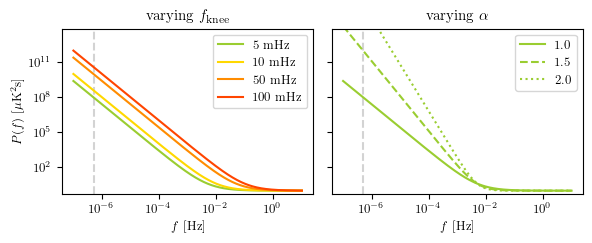

<Figure size 640x480 with 0 Axes>

In [8]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))

ax1.axvline(x=f_chunk_hz, color='lightgray', linestyle='dashed')

for i in range(len(f_knees)):
    ax1.loglog(ff[ff > 0], spectra_f_knee[i][ff > 0], color=colors_f_knee[i], label=f'{int(1000*f_knees[i])} mHz')

ax2.axvline(x=f_chunk_hz, color='lightgray', linestyle='dashed')

for i in range(len(alphas)):
    ax2.loglog(ff[ff > 0], spectra_alpha[i][ff > 0], linestyle=linestyles_alpha[i], color=colors_f_knee[0], label=f'{alphas[i]}')

ax1.set_title(r'varying $f_\mathrm{knee}$')    
ax1.set_xlabel(r'$f$ [Hz]')
ax1.set_ylabel(r'$P(f)$ [$\mu$K$^2$s]')
ax2.set_title(r'varying $\alpha$')    
ax2.set_xlabel(r'$f$ [Hz]')
ax2.set_yticklabels([])
ax1.legend(loc="upper right")
ax2.legend(loc="upper right")
ax1.set_ylim(y_min*0.5, y_max*0.6)
ax2.set_ylim(y_min*0.5, y_max*0.6)
plt.tight_layout()
plt.savefig('output/Pfs.pdf')
plt.show()
plt.clf()

### picking parameters

In [9]:
FWHM_arcmin = 20
omega_spin_rpm = 0.3
beta_deg = 57.5

omega_spin_arcminps = omega_spin_rpm*(360*60)/60
omega_LB_arcminps = np.sin(np.radians(beta_deg))*omega_spin_arcminps

dt_FWHM = FWHM_arcmin/omega_LB_arcminps

f_samp_hz = 3/dt_FWHM

print(f"sampling frequency from beam sampling = {f_samp_hz} Hz")

f_samp_hz = 2**29/365/24/3600

print(f"sampling frequency from year-long = {f_samp_hz} Hz")

f_samp_hz = 17.02

print(f"sampling frequency from year-long = {f_samp_hz} Hz")

# power of 2 that, given the sampling frequency, corresponds to a mission time of roughly 1 year
n_samples_pow = 2**np.ceil(np.log2(365*24*3600*f_samp_hz))

mission_time_days = n_samples_pow/f_samp_hz/3600/24

print(mission_time_days)

sampling frequency from beam sampling = 13.662941422168748 Hz
sampling frequency from year-long = 17.024064941653982 Hz
sampling frequency from year-long = 17.02 Hz
365.0871741306524


In [10]:
nside = 512

npix = hp.nside2npix(nside)

FWHM_rad = np.radians(FWHM_arcmin/60)

beam_area_str = np.pi*(FWHM_rad/2)**2
pixel_area_str = 4*np.pi/npix

print(f"for nside = {nside}")
print(f"area ratio = {beam_area_str/pixel_area_str}")
print(f"size ratio = {FWHM_arcmin/hp.nside2resol(nside, arcmin=True)}")

for nside = 512
area ratio = 6.654469074380578
size ratio = 2.9107959692700116


In [11]:
prec_period_min = 192.348

t_chunk_days = 365.09/16

print(f"how many spins in a chunk: {t_chunk_days/(1/omega_spin_rpm/60/24)}")
print(f"how many precs in a chunk: {t_chunk_days/(prec_period_min/60/24)}")

t_subchunk_days = 365.09/16/16

print(f"how many spins in a subchunk: {t_subchunk_days/(1/omega_spin_rpm/60/24)}")
print(f"how many precs in a subchunk: {t_subchunk_days/(prec_period_min/60/24)}")

how many spins in a chunk: 9857.429999999998
how many precs in a chunk: 170.82631480441694
how many spins in a subchunk: 616.0893749999999
how many precs in a subchunk: 10.676644675276059


In [12]:
n_chunks = 16
n_subchunks = 16

### Producing the input maps, pointings and TOD using litebird_sim
### Mission parameters
telescope = "MFT"
channel = "M1-195"
detectors = [
    "001_002_030_00A_195_B",
    "001_002_029_45B_195_B",
    "001_002_015_15A_195_T",
    "001_002_047_00A_195_B",
]
start_time = 51
detector_sampling_freq = f_samp_hz

# power of 2 that, given the sampling frequency, corresponds to a mission time of roughly 1 year
n_samples_pow = 2**np.ceil(np.log2(365*24*3600*detector_sampling_freq))

mission_time_days = n_samples_pow/detector_sampling_freq/3600/24

In [13]:
print(mission_time_days)

365.0871741306524


In [14]:
### Simulation parameters
nside = 128
lmax = 2*nside
random_seed = 45
imo_version = "vPTEP"
imo = lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION)
dtype_float = np.float64
tmp_dir = tempfile.TemporaryDirectory()
pol_angles = [0, np.pi/2, np.pi/4, 3*np.pi/4] # Pol angles for the 4 detectors, in radians (0, 45, 90 and 135 degrees).

### Detector list
detector_list = []
for i in range(len(detectors)):
    n_det = detectors[i]
    det = lbs.DetectorInfo.from_imo(
        url=f"/releases/{imo_version}/satellite/{telescope}/{channel}/{n_det}/detector_info",
        imo=imo,
    )
    det.sampling_rate_hz = detector_sampling_freq
    det.pol_angle_rad = pol_angles[i]
    det.fknee_mhz = 100
    det.alpha = 2.0
    detector_list.append(det)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [15]:
### Initializing the simulation
sim_long = lbs.Simulation(
    random_seed=random_seed,
    base_path=tmp_dir.name,
    name="brahmap_example",
    start_time=start_time,
    duration_s=mission_time_days * 24 * 60 * 60.0,
    imo=imo,
)
### Instrument definition
sim_long.set_instrument(
    lbs.InstrumentInfo.from_imo(
        imo,
        f"/releases/{imo_version}/satellite/{telescope}/instrument_info",
    )
)
### Create observations
sim_long.create_observations(
    detectors=detector_list,
    num_of_obs_per_detector=n_chunks,
    n_blocks_det=1,
    n_blocks_time=1,
    split_list_over_processes=False,
    tod_dtype=dtype_float,
)

### Scanning strategy
sim_long.set_scanning_strategy(
    imo_url=f"/releases/{imo_version}/satellite/scanning_parameters/"
)

### Prepare pointings
sim_long.prepare_pointings()

### Compute pointings (optional)
sim_long.precompute_pointings(pointings_dtype=dtype_float)

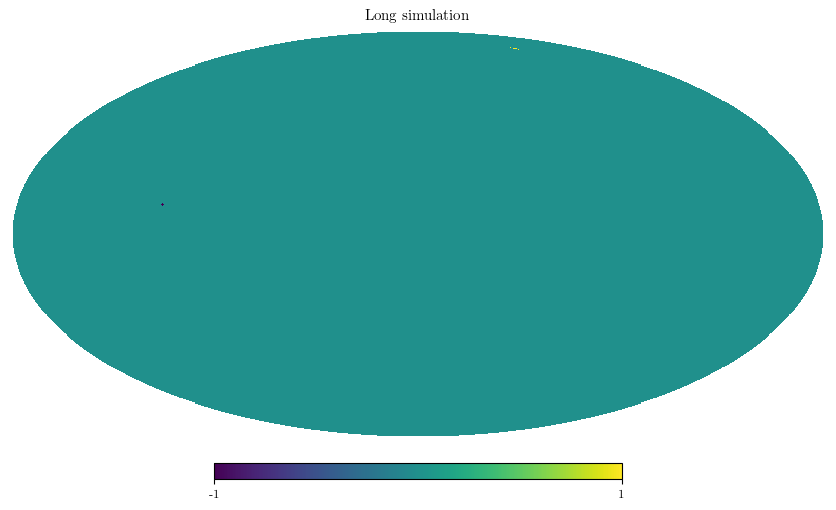

In [16]:
ptgs_long = sim_long.observations[0].pointing_matrix

ptg_start = ptgs_long[0,0]
ptg_end = ptgs_long[0,-1]

pix_start = hp.ang2pix(64, ptg_start[0], ptg_start[1])
pix_end = hp.ang2pix(64, ptg_end[0], ptg_end[1])

map_long = np.zeros(hp.nside2npix(64))

map_long[pix_start] = 1
map_long[pix_end] = -1

hp.mollview(map_long, title="Long simulation")

In [17]:
### Adding 1/f noise
lbs.noise.add_noise_to_observations(
    sim_long.observations, "one_over_f", dets_random=sim_long.dets_random
)

### Producing the GLS maps
fknees_mhz = sim_long.observations[0].fknee_mhz
fmins_hz = sim_long.observations[0].fmin_hz
alphas = sim_long.observations[0].alpha
nets_ukrts = sim_long.observations[0].net_ukrts
sampling_rate_hz = sim_long.observations[0].sampling_rate_hz

sigmas = nets_ukrts * np.sqrt(sampling_rate_hz) / 1e6 #as in rescale_noise

In [17]:
# Creating a dictionary of circulant power spectrum
ps_dict_circ_long = {}

for det_idx in range(len(detectors)):
    
    n_samples_new = sim_long.observations[0].n_samples
    
    fknee_mhz = fknees_mhz[det_idx]
    fmin_hz = fmins_hz[det_idx]
    alpha = alphas[det_idx]
    net_ukrts = nets_ukrts[det_idx]
    sigma = sigmas[det_idx]

    freqs = np.abs(np.fft.fftfreq(n_samples_new, d=1/sampling_rate_hz)) #2*n_samples!
    P_oof = sigma**2*(freqs**alpha + (fknee_mhz*1e-3)**alpha)/(freqs**alpha + fmin_hz**alpha)*len(freqs)

    ps_dict_circ_long[detectors[det_idx]] = P_oof

In [ ]:
isolver_threshold = 1e-15 #absolute tolerance of cg 

: 

In [ ]:
### Creating an inverse noise covariance operator (unit diagonal operator in this case)
inv_cov = brahmap.LBSim_InvNoiseCovLO_Circulant(
    obs=sim_long.observations,
    input=ps_dict_circ_long,
)

### Defining the parameters used for GLS map-making
# Since we are solving only for I, Q, and U maps, it is necessary to set the solver type to IQU
gls_params = brahmap.LBSimGLSParameters(
    solver_type=brahmap.SolverType.IQU,  # default value
    isolver_threshold=isolver_threshold,
)

### Computing the GLS maps
gls_result = brahmap.LBSim_compute_GLS_maps(
    nside=nside,
    observations=sim_long.observations,
    components="tod",
    inv_noise_cov_operator=inv_cov,
    dtype_float=dtype_float,
    LBSim_gls_parameters=gls_params,
)

output_maps_long = gls_result.GLS_maps


In [ ]:
Nl_long = hp.anafast(output_maps_long, lmax=lmax)[2]

In [ ]:
### Initializing the simulation
sim_short = lbs.Simulation(
    random_seed=random_seed,
    base_path=tmp_dir.name,
    name="brahmap_example",
    start_time=start_time,
    duration_s=mission_time_days * 24 * 60 * 60.0,
    imo=imo,
)
### Instrument definition
sim_short.set_instrument(
    lbs.InstrumentInfo.from_imo(
        imo,
        f"/releases/{imo_version}/satellite/{telescope}/instrument_info",
    )
)
### Create observations
sim_short.create_observations(
    detectors=detector_list,
    num_of_obs_per_detector=n_chunks*n_subchunks,
    n_blocks_det=1,
    n_blocks_time=1,
    split_list_over_processes=False,
    tod_dtype=dtype_float,
)

In [ ]:
n_samples_short = sim_short.observations[0].n_samples

for i in range(n_chunks):
    for j in range(n_subchunks):
        sim_short.observations[i*n_subchunks + j].tod[:] = sim_long.observations[i].tod[:,j*n_samples_short:(j+1)*n_samples_short]

In [ ]:
### Scanning strategy
sim_short.set_scanning_strategy(
    imo_url=f"/releases/{imo_version}/satellite/scanning_parameters/"
)

### Prepare pointings
sim_short.prepare_pointings()

### Compute pointings (optional)
sim_short.precompute_pointings(pointings_dtype=dtype_float)

: 

In [ ]:
ptgs_short = sim_short.observations[0].pointing_matrix

ptg_start = ptgs_short[0,0]
ptg_end = ptgs_short[0,-1]

pix_start = hp.ang2pix(64, ptg_start[0], ptg_start[1])
pix_end = hp.ang2pix(64, ptg_end[0], ptg_end[1])

map_short = np.zeros(hp.nside2npix(64))

map_short[pix_start] = 1
map_short[pix_end] = -1

hp.mollview(map_short, title="Short simulation")

In [ ]:
# Creating a dictionary of circulant power spectrum
ps_dict_circ_short = {}

for det_idx in range(len(detectors)):
    
    n_samples_new = sim_short.observations[0].n_samples
    
    fknee_mhz = fknees_mhz[det_idx]
    fmin_hz = fmins_hz[det_idx]
    alpha = alphas[det_idx]
    net_ukrts = nets_ukrts[det_idx]
    sigma = sigmas[det_idx]

    freqs = np.abs(np.fft.fftfreq(n_samples_new, d=1/sampling_rate_hz))
    P_oof = sigma**2*(freqs**alpha + (fknee_mhz*1e-3)**alpha)/(freqs**alpha + fmin_hz**alpha)*len(freqs)

    ps_dict_circ_short[detectors[det_idx]] = P_oof


### Creating an inverse noise covariance operator (unit diagonal operator in this case)
inv_cov = brahmap.LBSim_InvNoiseCovLO_Circulant(
    obs=sim_short.observations,
    input=ps_dict_circ_short,
)

### Defining the parameters used for GLS map-making
# Since we are solving only for I, Q, and U maps, it is necessary to set the solver type to IQU
gls_params = brahmap.LBSimGLSParameters(
    solver_type=brahmap.SolverType.IQU,  # default value
)

In [ ]:
### Computing the GLS maps
gls_result = brahmap.LBSim_compute_GLS_maps(
    nside=nside,
    observations=sim_short.observations,
    components="tod",
    inv_noise_cov_operator=inv_cov,
    dtype_float=dtype_float,
    LBSim_gls_parameters=gls_params,
)

output_maps_short = gls_result.GLS_maps


-------------------------- ProcessTimeSamples Summary --------------------------
Processed 134217728 time samples for npix=196608
Found 0 pathological pixels on the map
Map-maker will take into account only 196608 pixels
--------------------------------------------------------------------------------


In [ ]:
Nl_short = hp.anafast(output_maps_short, lmax=lmax)[2]

/var/folders/wl/0xvr4dp16v1dx8h0clwghf6r0000gn/T/ipykernel_58031/1390776297.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


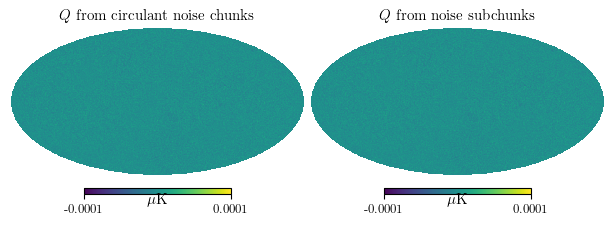

In [ ]:
### Plotting and comparing the input and output maps
plt.figure(figsize=(6, 2.5))

hp.mollview(output_maps_long[1], sub=121, title=r"$Q$ from circulant noise chunks", min=-1e-4, max=1e-4, unit=r"$\mu$K")
hp.mollview(output_maps_short[1], sub=122, title=r"$Q$ from noise subchunks", min=-1e-4, max=1e-4, unit=r"$\mu$K")

plt.tight_layout()
plt.savefig('output/Q_subchunks.pdf')
plt.show()

### INPAINTING

In [ ]:
# ntot = sampling_rate_hz*3600*24*mission_time_days
# print(f"total samples = {int(ntot)}")
# print(f"chunk samples = {int(ntot/16)}")
# print(f"subch samples = {int(ntot/16/16)}")

# components = ["tod"]

# i = 0

# for obs in sim_short.observations:
#     print(i)
    
#     i += 1
    
#     print(len(obs.tod[0]))
#      #   tod_temp = obs.tod[det_idx]
#       #  print(len(tod_temp))

In [ ]:
# Creating a dictionary of circulant power spectrum
ps_dict_circ_short_inpainted = {}

for det_idx in range(len(detectors)):
    
    n_samples_new = sim_short.observations[0].n_samples*2 #DOUBLE THE NUMBER OF SAMPLES
    
    fknee_mhz = fknees_mhz[det_idx]
    fmin_hz = fmins_hz[det_idx]
    alpha = alphas[det_idx]
    net_ukrts = nets_ukrts[det_idx]
    sigma = sigmas[det_idx]

    freqs = np.abs(np.fft.fftfreq(n_samples_new, d=1/sampling_rate_hz))
    P_oof = sigma**2*(freqs**alpha + (fknee_mhz*1e-3)**alpha)/(freqs**alpha + fmin_hz**alpha)*len(freqs)

    ps_dict_circ_short_inpainted[detectors[det_idx]] = P_oof

In [ ]:
### Creating an inverse noise covariance operator (unit diagonal operator in this case)
inv_cov = brahmap.LBSim_InvNoiseCovLO_Circulant(
    obs=sim_short.observations,
    input=ps_dict_circ_short_inpainted,
    inpainting=True,
)

In [ ]:
### Defining the parameters used for GLS map-making
# Since we are solving only for I, Q, and U maps, it is necessary to set the solver type to IQU
gls_params = brahmap.LBSimGLSParameters(
    solver_type=brahmap.SolverType.IQU,  # default value
)

In [ ]:
nn = detector_sampling_freq/(fknee_mhz*1e-3)
print(nn)

print(n_samples_short/8)

20.0
16384.0


: 

In [ ]:
### Computing the GLS maps
gls_result = brahmap.LBSim_compute_GLS_maps(
    nside=nside,
    observations=sim_short.observations,
    components="tod",
    inv_noise_cov_operator=inv_cov,
    dtype_float=dtype_float,
    LBSim_gls_parameters=gls_params,
    inpainting=True,
)


-------------------------- ProcessTimeSamples Summary --------------------------
Processed 268435456 time samples for npix=198656
Found 0 pathological pixels on the map
Map-maker will take into account only 198656 pixels
--------------------------------------------------------------------------------


/Users/marta/WORK/map-making_AGAIN/BrahMap/brahmap/lbsim/lbsim_GLS.py:264: ComplexWarning: Casting complex values to real discards the imaginary part
  time_ordered_data[start_idx:end_idx] = x_sol_10_binned_spline


In [ ]:
output_maps_short_inpainting = gls_result.GLS_maps

/var/folders/wl/0xvr4dp16v1dx8h0clwghf6r0000gn/T/ipykernel_54863/3680554613.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


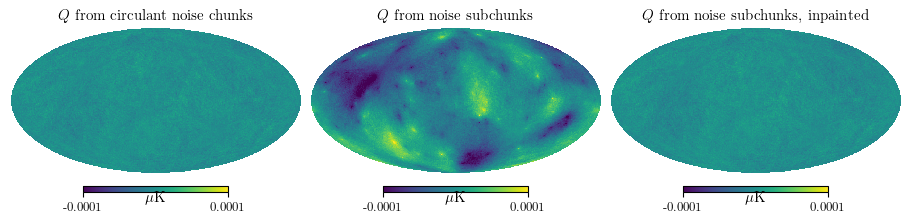

In [ ]:
### Plotting and comparing the input and output maps
plt.figure(figsize=(9, 2.5))

hp.mollview(output_maps_long[1], sub=131, title=r"$Q$ from circulant noise chunks", min=-1e-4, max=1e-4, unit=r"$\mu$K")
hp.mollview(output_maps_short[1], sub=132, title=r"$Q$ from noise subchunks", min=-1e-4, max=1e-4, unit=r"$\mu$K")
hp.mollview(output_maps_short_inpainting[1], sub=133, title=r"$Q$ from noise subchunks, inpainted", min=-1e-4, max=1e-4, unit=r"$\mu$K")

plt.tight_layout()
plt.savefig('output/Q_subchunks.pdf')
plt.show()

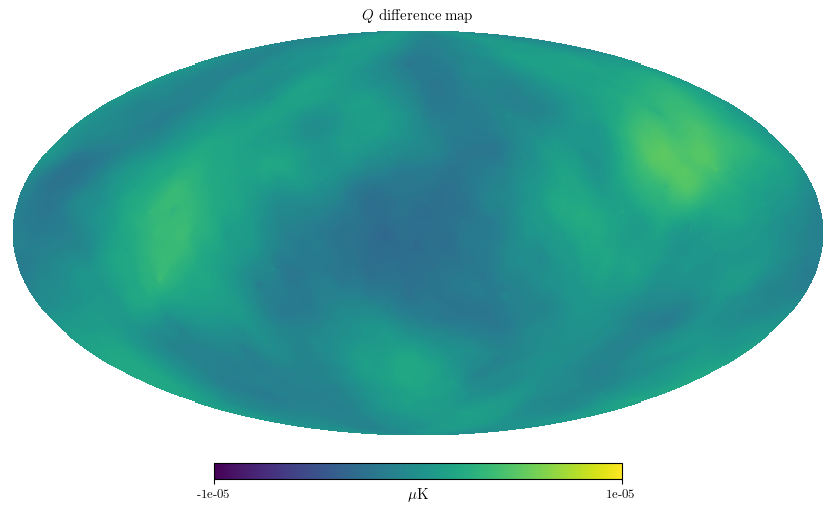

In [ ]:
hp.mollview(output_maps_long[1] - output_maps_short_inpainting[1], title=r"$Q$ difference map", min=-1e-5, max=1e-5, unit=r"$\mu$K")

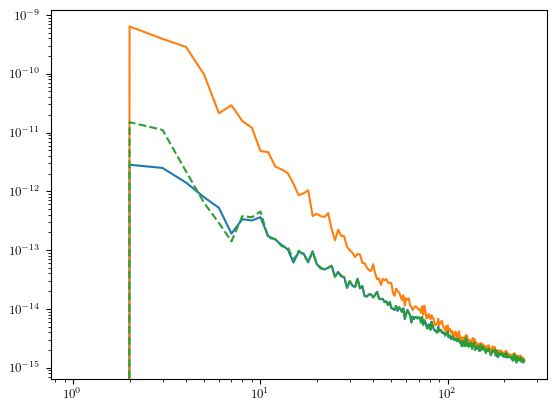

In [ ]:
Nl_short_inpainted = hp.anafast(output_maps_short_inpainting, lmax=lmax)[2]

plt.loglog(Nl_long)
plt.loglog(Nl_short)
plt.loglog(Nl_short_inpainted, linestyle="dashed")

In [ ]:
quit()

simulating 1.0539327485380117 hours of data at 19 Hz


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


it took 11.696200132369995 seconds to converge!


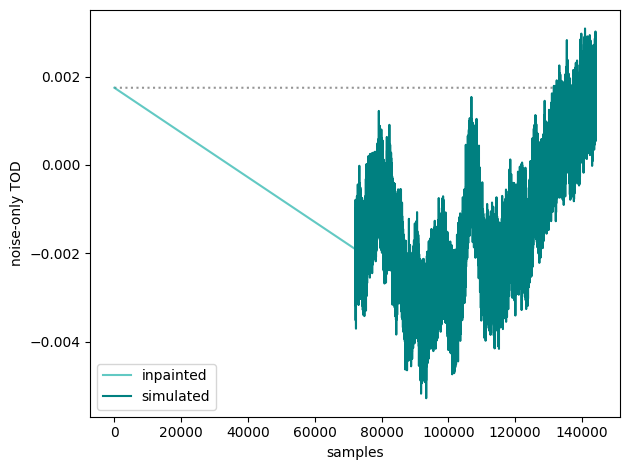

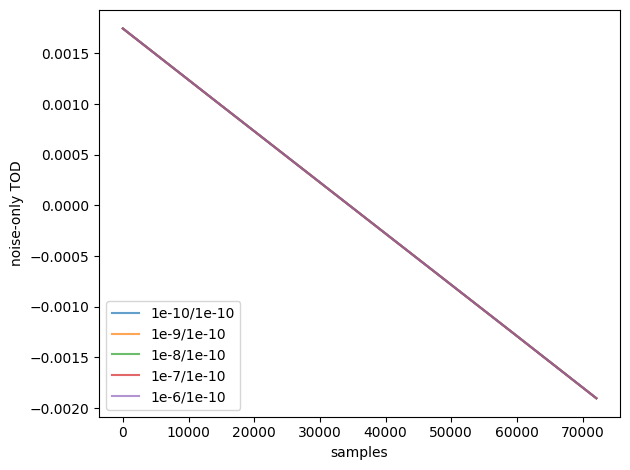

it took 0.037432193756103516 seconds to converge!


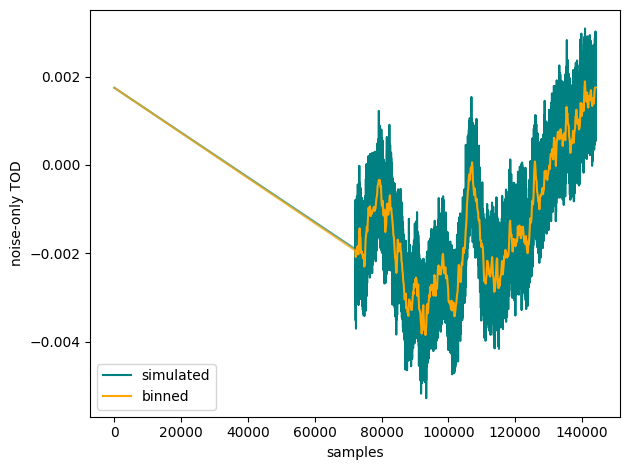

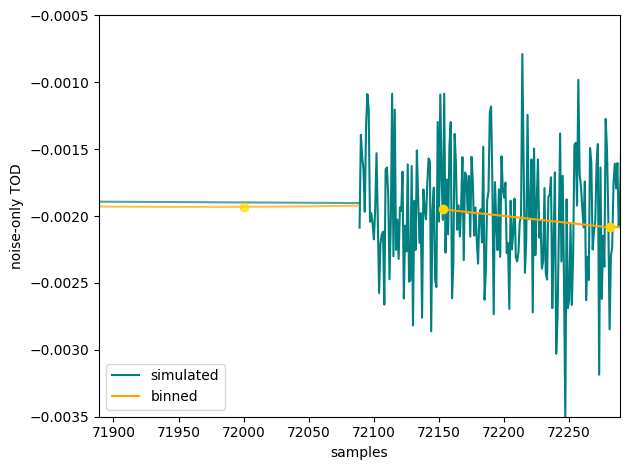

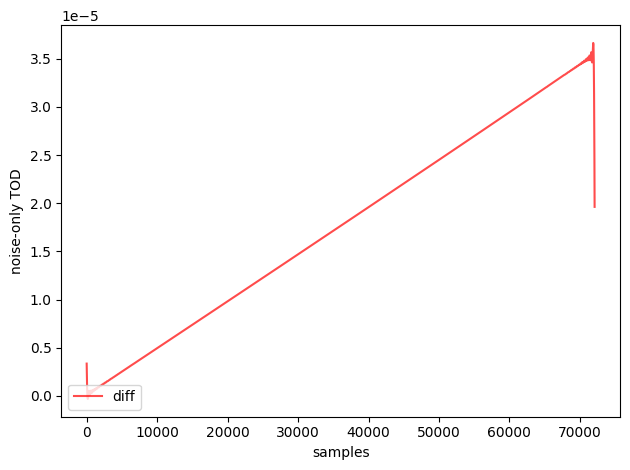

simulating 33.72612573099415 hours of data at 19 Hz
95.0
it took 25.388361930847168 seconds to converge!


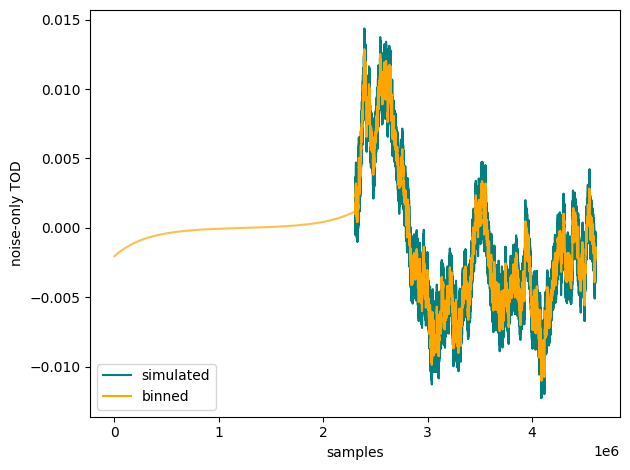

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import scipy as sp

from scipy.sparse.linalg import cg, LinearOperator
from scipy.interpolate import CubicSpline

from matplotlib import pyplot as plt
import time

import litebird_sim as lbs
####################################################
# DEFINE FUCTIONS FOR INPAINTING
####################################################

def P_oof_inv_func(N, sampling_rate_hz, net_ukrts, fknee_mhz, alpha, fmin_hz):
    '''
    Given N, the sampling rate and all 1/f noise parameters, returns P^-1
    '''
    sigma = net_ukrts * np.sqrt(sampling_rate_hz) / 1e6     # as in LBS rescale_noise
    freqs = sp.fft.rfftfreq(N, d=1/sampling_rate_hz)
    P_oof_inv = 1/(sigma**2*(freqs**alpha + (fknee_mhz*1e-3)**alpha)/(freqs**alpha + fmin_hz**alpha)*len(freqs))
    return P_oof_inv

def A_func_left(Pinv, y, N):   
    '''
    Given y, pads it to the left and returns the first len(y) elements of IDFT(1/P * DFT[0,y]))
    
    ARGUMENTS____________________________________________ 
    Pinv:  inverse of the power spectrum
    y:     vector to be padded
    ''' 
    n = len(y)
    z = np.concatenate((np.zeros(N-n), y))
    z_fft = sp.fft.rfft(z)
    product = Pinv * z_fft
    result = sp.fft.irfft(product)
    return result[:N-n]
### "Exact" solution for a 1-hour chunk (19 Hz)
####################################################
# PARAMETERS
####################################################

nsamp = int(2**16*1.1) #slightly over 2^n to avoid circulancy

sampling_rate_hz=19
duration_s=nsamp/sampling_rate_hz

print(f'simulating {duration_s/3600} hours of data at {sampling_rate_hz} Hz')

net_ukrts=100
alpha=2
fknee_mhz=100
fmin_hz=1e-5

# total length of the inpainted TOD
nsamp_inpainted = 2*nsamp
####################################################
# GENERATE NOISE REALIZATION
####################################################

imo_version = "vPTEP"
imo = lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION)
dtype_float = np.float64

sim = lbs.Simulation(
    base_path='output',
    start_time=0,
    duration_s=duration_s,
    random_seed=12345,
    imo=imo,
)

det = lbs.DetectorInfo(
  net_ukrts=net_ukrts,
  sampling_rate_hz=sampling_rate_hz,
  alpha=alpha,
  fknee_mhz=fknee_mhz,
  fmin_hz=fmin_hz
)

obs = sim.create_observations(detectors=[det])

# adding noise to the TOD
lbs.noise.add_noise_to_observations(obs, noise_type='one_over_f', dets_random=sim.dets_random)

TOD_oof = obs[0].tod[0]

####################################################
# INPAINT
####################################################

# inverse of the 1/f power spectra
P_oof_inv = P_oof_inv_func(nsamp_inpainted, sampling_rate_hz, net_ukrts, fknee_mhz, alpha, fmin_hz)

# -IDFT(1/P * DFT([0,y]))
b = -A_func_left(P_oof_inv, TOD_oof, nsamp_inpainted)

lenx = nsamp_inpainted-nsamp

# we need a function of x only to build the LinearOperator for CG
def A_func_x_only(x):   
    '''
    Given x, computes A_func(P_oof_inv, x, nsamp_inpainted, right=True)
    ''' 
    z = np.concatenate((x, np.zeros(nsamp)))
    z_fft = sp.fft.rfft(z)
    product = P_oof_inv * z_fft
    result = sp.fft.irfft(product)
    return result[:lenx]

# define the LinearOperator for CG
A_op = LinearOperator((lenx,lenx), matvec=A_func_x_only)

### initial guess for x
avg_head = np.mean(TOD_oof[:10])
avg_tail = np.mean(TOD_oof[-10:])
x0 = avg_tail + np.arange(lenx)/lenx*(avg_head-avg_tail)

start = time.time()

x_sol_10, info = cg(A_op, b, x0=x0, rtol=1e-10)

if info == 0:
    print("it took "+str((time.time()-start))+" seconds to converge!")
else:
    print("CG did not converge, info =", info)
plt.plot(np.arange(nsamp_inpainted),np.ones(nsamp_inpainted)*x_sol_10[0], color='dimgrey', alpha=0.7, linestyle=':')
plt.plot(np.arange(lenx),x_sol_10, color='lightseagreen', alpha=0.7, label='inpainted')
plt.plot(lenx+np.arange(nsamp),TOD_oof, color='teal', label='simulated')
plt.xlabel('samples')
plt.ylabel('noise-only TOD')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()
plt.clf()

##### Testing different rtol
x_sol_09, info = cg(A_op, b, rtol=1e-9)
x_sol_08, info = cg(A_op, b, rtol=1e-8)
x_sol_07, info = cg(A_op, b, rtol=1e-7)
x_sol_06, info = cg(A_op, b, rtol=1e-6)
plt.plot(np.arange(nsamp),x_sol_10, alpha=0.7, label='1e-10/1e-10')
plt.plot(np.arange(nsamp),x_sol_09, alpha=0.7, label='1e-9/1e-10')
plt.plot(np.arange(nsamp),x_sol_08, alpha=0.7, label='1e-8/1e-10')
plt.plot(np.arange(nsamp),x_sol_07, alpha=0.7, label='1e-7/1e-10')
plt.plot(np.arange(nsamp),x_sol_06, alpha=0.7, label='1e-6/1e-10')
plt.xlabel('samples')
plt.ylabel('noise-only TOD')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()
plt.clf()

##### Testing binning the TOD + interpolation (spline)
nn = 128

TOD_oof_binned = np.empty(int(nsamp/nn))

for i in range(len(TOD_oof_binned)):
    TOD_oof_binned[i] = np.mean(TOD_oof[i*nn:(i+1)*nn])

nsamp_binned = len(TOD_oof_binned)
nsamp_inpainted_binned = 2*nsamp_binned

nyquist_binned = sampling_rate_hz/2/nn

freqs = sp.fft.rfftfreq(nsamp_inpainted, d=1/sampling_rate_hz)
mask_freqs = np.where(freqs<=nyquist_binned)

# inverse of the 1/f power spectra
P_oof_inv_binned = P_oof_inv[mask_freqs]*nn

# -IDFT(1/P * DFT([0,y]))
b_binned = -A_func_left(P_oof_inv_binned, TOD_oof_binned, nsamp_inpainted_binned)
lenx_binned = nsamp_inpainted_binned - nsamp_binned

# we need a function of x only to build the LinearOperator for CG
def A_func_x_only_binned(x):   
    '''
    Given x, computes A_func(P_oof_inv, x, nsamp_inpainted, right=True)
    ''' 
    z = np.concatenate((x, np.zeros(nsamp_binned)))
    z_fft = sp.fft.rfft(z)
    product = P_oof_inv_binned * z_fft
    result = sp.fft.irfft(product)
    return result[:lenx_binned]

# Define the LinearOperator for CG
A_op_binned = LinearOperator((lenx_binned,lenx_binned), matvec=A_func_x_only_binned)

x0 = avg_tail + np.arange(lenx_binned)/lenx_binned*(avg_head-avg_tail)

start = time.time()

x_sol_10_binned, info = cg(A_op_binned, b_binned, x0=x0, rtol=1e-10)

if info == 0:
    print("it took "+str((time.time()-start))+" seconds to converge!")
else:
    print("CG did not converge, info =", info)
x = nn*(1/2 + np.arange(nsamp_binned))
y = x_sol_10_binned
cs = CubicSpline(x, y)

x_sol_10_binned_spline = cs(np.arange(nsamp))
plt.plot(np.arange(nsamp),x_sol_10, alpha=0.7, color='teal')
plt.plot(nsamp+np.arange(nsamp),TOD_oof, color='teal', label='simulated')
plt.plot(np.arange(nsamp), x_sol_10_binned_spline, alpha=0.7, color='orange')
plt.plot(nsamp+nn*(1/2+np.arange(nsamp_binned)),TOD_oof_binned, color='orange', label='binned')
plt.xlabel('samples')
plt.ylabel('noise-only TOD')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()
#plt.savefig('output/simulated+inpainted.pdf')
plt.clf()
plt.plot(np.arange(nsamp),x_sol_10, alpha=0.7, color='teal')
plt.plot(nsamp+np.arange(nsamp),TOD_oof, color='teal', label='simulated')
plt.plot(np.arange(nsamp), x_sol_10_binned_spline, alpha=0.7, color='orange')
plt.plot(x,y,'o',alpha=0.7,color='gold')
plt.plot(nsamp+nn*(1/2+np.arange(nsamp_binned)),TOD_oof_binned, color='orange', label='binned')
plt.plot(nsamp+nn*(1/2+np.arange(nsamp_binned)),TOD_oof_binned,'o',color='gold')
plt.xlabel('samples')
plt.ylabel('noise-only TOD')
plt.legend(loc='lower left')
plt.xlim((nsamp-200,nsamp+200))
plt.ylim((-0.0035,-0.0005))
plt.tight_layout()
plt.show()
#plt.savefig('output/simulated+inpainted.pdf')
plt.clf()
plt.plot(x_sol_10-x_sol_10_binned_spline, alpha=0.7, color='red', label='diff')
plt.xlabel('samples')
plt.ylabel('noise-only TOD')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()
#plt.savefig('output/simulated+inpainted.pdf')
plt.clf()
### Trying for a 34 hour chunk (19 Hz)
####################################################
# PARAMETERS
####################################################

nsamp = int(2**21*1.1) #slightly over 2^n to avoid circulancy

sampling_rate_hz=19
duration_s=nsamp/sampling_rate_hz

print(f'simulating {duration_s/3600} hours of data at {sampling_rate_hz} Hz')

net_ukrts=100
alpha=2
fknee_mhz=100
fmin_hz=1e-5

# total length of the inpainted TOD
nsamp_inpainted = 2*nsamp
####################################################
# GENERATE NOISE REALIZATION
####################################################

sim = lbs.Simulation(
    base_path='output',
    start_time=0,
    duration_s=duration_s,
    random_seed=12345,
    imo=imo,
)

det = lbs.DetectorInfo(
  net_ukrts=net_ukrts,
  sampling_rate_hz=sampling_rate_hz,
  alpha=alpha,
  fknee_mhz=fknee_mhz,
  fmin_hz=fmin_hz
)

obs = sim.create_observations(detectors=[det])

# adding noise to the TOD
lbs.noise.add_noise_to_observations(obs, noise_type='one_over_f', dets_random=sim.dets_random)

TOD_oof = obs[0].tod[0]
####################################################
# INPAINT
####################################################

# inverse of the 1/f power spectra
P_oof_inv = P_oof_inv_func(nsamp_inpainted, sampling_rate_hz, net_ukrts, fknee_mhz, alpha, fmin_hz)

nyquist = sampling_rate_hz/2
ratio = nyquist/(fknee_mhz*1e-3)
print(ratio)
nn = 100

TOD_oof_binned = np.empty(int(nsamp/nn))

for i in range(len(TOD_oof_binned)):
    TOD_oof_binned[i] = np.mean(TOD_oof[i*nn:(i+1)*nn])

nsamp_binned = len(TOD_oof_binned)
nsamp_inpainted_binned = 2*nsamp_binned

nyquist_binned = sampling_rate_hz/2/nn

freqs = sp.fft.rfftfreq(nsamp_inpainted, d=1/sampling_rate_hz)
mask_freqs = np.where(freqs<=nyquist_binned)

# inverse of the 1/f power spectra
P_oof_inv_binned = P_oof_inv[mask_freqs]*nn

# -IDFT(1/P * DFT([0,y]))
b_binned = -A_func_left(P_oof_inv_binned, TOD_oof_binned, nsamp_inpainted_binned)
lenx_binned = nsamp_inpainted_binned - nsamp_binned

# we need a function of x only to build the LinearOperator for CG
def A_func_x_only_binned(x):   
    '''
    Given x, computes A_func(P_oof_inv, x, nsamp_inpainted, right=True)
    ''' 
    z = np.concatenate((x, np.zeros(nsamp_binned)))
    z_fft = sp.fft.rfft(z)
    product = P_oof_inv_binned * z_fft
    result = sp.fft.irfft(product)
    return result[:lenx_binned]

# Define the LinearOperator for CG
A_op_binned = LinearOperator((lenx_binned,lenx_binned), matvec=A_func_x_only_binned)

x0 = avg_tail + np.arange(lenx_binned)/lenx_binned*(avg_head-avg_tail)

start = time.time()

x_sol_10_binned, info = cg(A_op_binned, b_binned, x0=x0, rtol=1e-10)

if info == 0:
    print("it took "+str((time.time()-start))+" seconds to converge!")
else:
    print("CG did not converge, info =", info)
x = nn*(1/2 + np.arange(nsamp_binned))
y = x_sol_10_binned
cs = CubicSpline(x, y)

x_sol_10_binned_spline = cs(np.arange(nsamp))
#plt.plot(np.arange(nsamp),x_sol_10, alpha=0.7, color='teal')
plt.plot(nsamp+np.arange(nsamp),TOD_oof, color='teal', label='simulated')
plt.plot(np.arange(nsamp), x_sol_10_binned_spline, alpha=0.7, color='orange')
plt.plot(nsamp+nn*(1/2+np.arange(nsamp_binned)),TOD_oof_binned, color='orange', label='binned')
plt.xlabel('samples')
plt.ylabel('noise-only TOD')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()
#plt.savefig('output/simulated+inpainted.pdf')
plt.clf()

